In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # base font size
    "axes.labelsize": 18,     # x and y labels
    "axes.titlesize": 18,     # title
    "legend.fontsize": 14,    # legend
    "xtick.labelsize": 14,    # x tick labels
    "ytick.labelsize": 14,    # y tick labels
})

import sys
import os
import copy

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code")) 

In [2]:
from halo_model.halos.base.mass_converter import NFWMassConverter
from halo_model.config.config import Config
from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.r_vir.models.SO import R_virSO
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.stellar_truncated_powerlaw import ProfileStellarTruncatedPowerLaw
from halo_model.halos.base.profile.models.gas_cored_powerlaw import ProfileGasCoredPowerLaw

from halo_model.halos.base.shmr.models.moster2013 import SMHRMoster2013

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import romb

from halo_model.algorithms.downhill_simplex import downhill_simplex
from halo_model.algorithms.fourier import fourier

sys.path.append(os.path.abspath("/home/milan/Desktop/thesis/code/plotting_code/stellar_profile")) 

cfg = Config()

In [3]:
R_vir = R_virSO(cfg)
c = ConcentrationNeto2007(cfg)
smhr = SMHRMoster2013(cfg, c)

dmprofile = ProfileNFW(c, R_vir)
stellarprofile = ProfileStellarTruncatedPowerLaw(cfg, smhr, c)

Computing Fourier transform of stellar profile...


128
r_vir: 0.1626248951627506
r_vir: 0.754837897454872


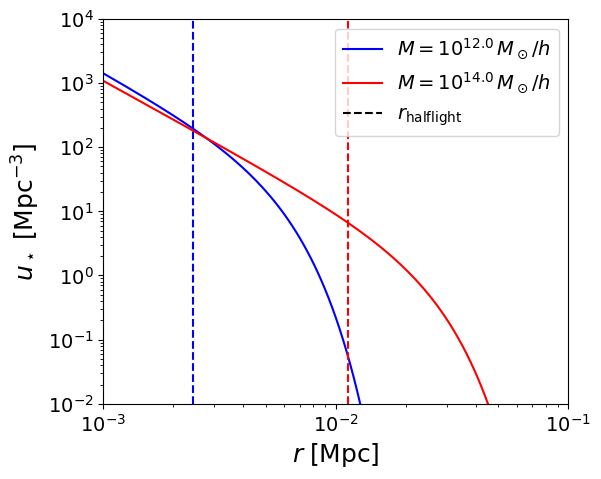

In [4]:
cfg.massdef = "200c"

z = 0
rmin, rmax = 1e-3, 1e-1
Nr = 2**7
print(Nr)
r_grid = np.geomspace(rmin, rmax, Nr + 1)

plt.figure(figsize=(6,5))
for M, color in zip([1e12, 1e14], ['blue', 'red']):
    r_vir = R_virSO(cfg).R_vir(cfg.cosmo, M, z)
    print("r_vir:", r_vir)

    rho_gas_grid = stellarprofile.real(cfg.cosmo, r_grid, M, z)
    normalization = romb(r_grid*rho_gas_grid, np.log(r_grid[1]) - np.log(r_grid[0]))    
    rho_gas_grid = rho_gas_grid/normalization
    
    plt.plot(
        r_grid,
        rho_gas_grid,
        label=rf"$M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
        color = color
    )
    r_halflight = 0.015*r_vir
    r_eject = 6*r_vir
    plt.vlines(r_halflight, ymin=1e-2, ymax=1e4, linestyle='--', color=color)
    
plt.plot([], [], 'k--', label=r"$r_\mathrm{halflight}$")

plt.xscale("log")
plt.xlim(rmin, rmax)
plt.ylim(1e-2, 1e4)
plt.yscale("log")
plt.ylabel(r"$u_\star \; [\mathrm{Mpc}^{-3}]$")
plt.xlabel(r"$r  \; [\mathrm{Mpc}]$")
plt.legend(loc="upper right")
plt.savefig("normalized_stellar_profile_real_space_mass_comparison.pdf",
            bbox_inches="tight")
plt.show()

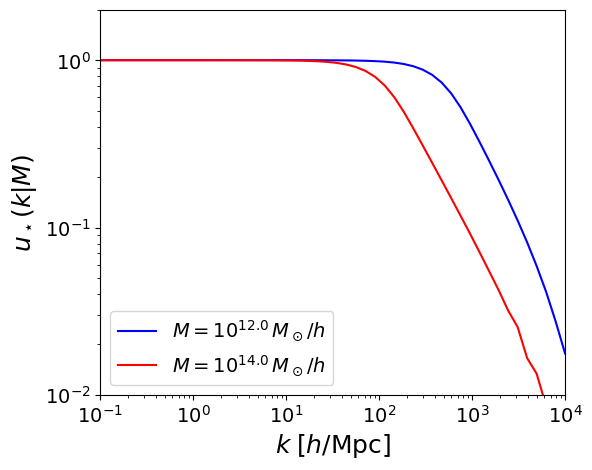

In [11]:
k_grid = np.geomspace(1e-1, 1e4, 50)

def fit_gas(k, k_pivot, alpha, beta):
    return (1 + (k/k_pivot)**beta)**(alpha/beta)

plt.figure(figsize=(6,5))
for M, color in zip([1e12, 1e14], ['blue', 'red']):
    
    # plt.plot(k_grid, fourier_gas_grid, label=rf"$M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$")
    y_vals = stellarprofile.fourier(cfg.cosmo, k_grid, M, cfg.z)
    plt.plot(
        k_grid, 
        y_vals, 
        label=rf"$M = 10^{{{np.log10(M):.1f}}}\,M_\odot/h$",
        color = color,
        )
    r_vir = R_virSO(cfg).R_vir(cfg.cosmo, M, z)
    
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-1, 1e4)
plt.ylim(1e-2, 2)
plt.legend(loc="best")

plt.ylabel(r"$u_\star(k|M)$")
plt.xlabel(r"$k \;[h/\mathrm{Mpc}]$")
plt.savefig("normalized_gas_profile_fourier_space_mass_comparison.pdf",
            bbox_inches="tight")

plt.show()
